In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load scaled data for Linear Regression:
df = pd.read_csv("D:\Data Science\Sales Forecasting Project\Clean Dataset for modelling\walmart_features.csv")
display(df.head())

,store,dept,weekly_sales,is_holiday,store_type,store_size,temperature,fuel_price,markdown1,markdown2,...,unemployment,weekly_sales_log,unemployment_log,month,year,week_of_year,quarter,is_quarter_end,has_markdown,total_markdown
0,1,1,24924.50,0,0,151315,42.31,2.572,0.0,0.0,...,8.106,10.306097,2.208934,2,2010,5,1,0,0,0.0
1,1,1,46039.49,1,0,151315,38.51,2.548,0.0,0.0,...,8.106,10.840158,2.208934,2,2010,6,1,0,0,0.0
2,1,1,41595.55,0,0,151315,39.93,2.514,0.0,0.0,...,8.106,10.749044,2.208934,2,2010,7,1,0,0,0.0
3,1,1,19403.54,0,0,151315,46.63,2.561,0.0,0.0,...,8.106,10.102071,2.208934,2,2010,8,1,0,0,0.0
4,1,1,21827.90,0,0,151315,46.50,2.625,0.0,0.0,...,8.106,10.196823,2.208934,3,2010,9,1,0,0,0.0


In [3]:
# Define Features and Target:

feature_cols = [
    "store", "dept",
    "is_holiday", "store_type", "store_size",
    "temperature", "fuel_price",
    "markdown1", "markdown2", "markdown3",
    "markdown4", "markdown5",
    "cpi", "unemployment",
    "has_markdown", "total_markdown",
    "month", "year", "week_of_year",
    "quarter", "is_quarter_end"
]

target = "weekly_sales"    

X = df[feature_cols]
y = df[target]

In [4]:
# Train Test Split:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)


# Modelling Using RandomForestRegressor

In [5]:
# Train Random Forest:
from sklearn.ensemble import RandomForestRegressor
# n_estimators  → number of trees to build (100 is standard)
# max_depth     → how deep each tree can grow
#                 None = grow until pure (can overfit)
#                 Set to 20 for balance
# min_samples_split → minimum rows needed to split a node
# n_jobs        → -1 means use all CPU cores (faster training)
# random_state  → reproducible results

rf = RandomForestRegressor(
    n_estimators      = 100,
    max_depth         = 20,
    min_samples_split = 5,
    n_jobs            = -1,
    random_state      = 42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Predictions and Evaluation:

#Prediction on train data
ypred_train=rf.predict(X_train)
print('Train R2:',r2_score(y_train,ypred_train))

#prediction on test data:
ypred_test = rf.predict(X_test)
print('Test R2:',r2_score(y_test,ypred_test))

mae  = mean_absolute_error(y_test, ypred_test)
rmse = np.sqrt(mean_squared_error(y_test, ypred_test))
r2   = r2_score(y_test, ypred_test)


print("RANDOM FOREST — MODEL PERFORMANCE")

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Train R2: 0.9922752777330254
Test R2: 0.9729063742597983
RANDOM FOREST — MODEL PERFORMANCE
MAE  : $1,504.45
RMSE : $3,758.80
R²   : 0.9729


In [7]:
# STEP 5: Feature Importance:

importance_df = pd.DataFrame({
    "feature"   : feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n── Top 10 Feature Importances ──")
print(importance_df.head(10).to_string(index=False))


── Top 10 Feature Importances ──
     feature  importance
        dept    0.629074
  store_size    0.192994
       store    0.056896
week_of_year    0.038785
         cpi    0.025607
  store_type    0.014642
unemployment    0.010468
 temperature    0.009088
       month    0.007605
  fuel_price    0.004023


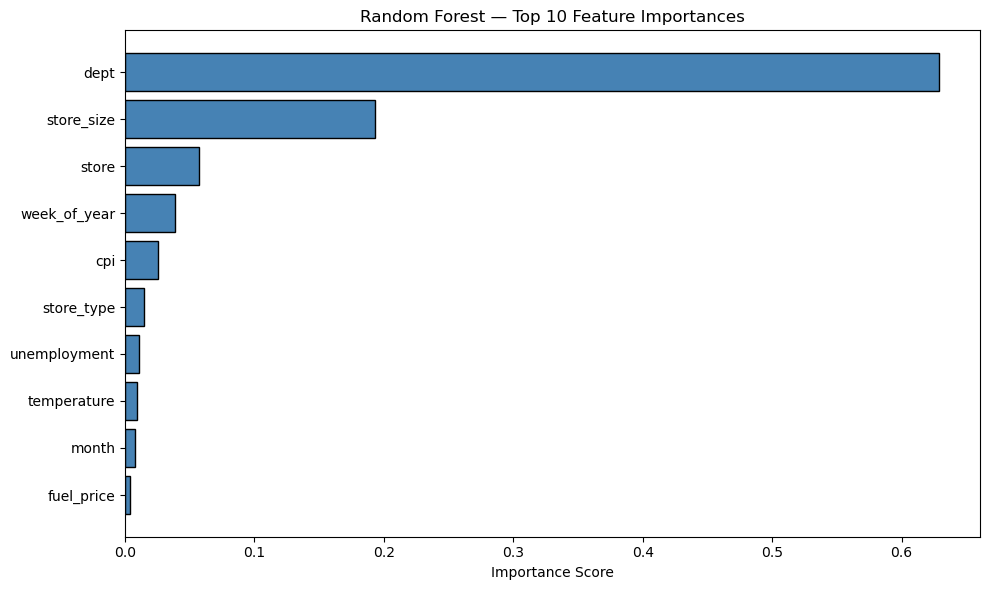

In [8]:
# Plot feature importance

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"][:10][::-1],
    importance_df["importance"][:10][::-1],
    color="steelblue", edgecolor="black"
)
plt.title("Random Forest — Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.show()

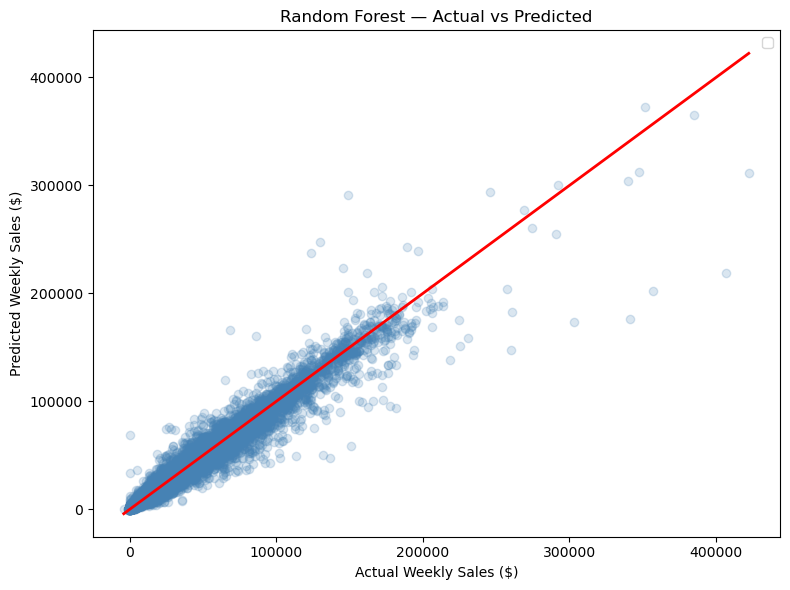

In [9]:
# Actual vs Predicted Plot:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, ypred_test, alpha=0.2, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Weekly Sales ($)")
plt.ylabel("Predicted Weekly Sales ($)")
plt.title("Random Forest — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#  Save Model:
os.makedirs("models", exist_ok=True)
joblib.dump(rf, "models/random_forest.pkl")
print("\n model saved → models/random_forest.pkl")


 model saved → models/random_forest.pkl


# Modelling Using XGBOOST

In [11]:
# Train XGBoost:
from xgboost import XGBRegressor
# n_estimators   → number of trees (300 is good starting point)
# learning_rate  → how much each tree corrects previous errors
#                  lower = slower but better (0.05-0.1 is good)
# max_depth      → tree depth (6 is standard for XGBoost)
# subsample      → use 80% of rows per tree (prevents overfit)
# colsample_bytree → use 80% of features per tree
# n_jobs         → -1 = all CPU cores

xgb = XGBRegressor(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 8,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,     # reduces overfitting
    n_jobs            = -1,
    random_state      = 42,
    verbosity         = 0,     # Suppress training logs
)

xgb.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],  # Monitor test performance
    verbose               = 100   # Print progress every 50 trees
)

[0]	validation_0-rmse:21930.42183
[100]	validation_0-rmse:6516.66605
[200]	validation_0-rmse:5342.99120
[300]	validation_0-rmse:4884.68855
[400]	validation_0-rmse:4543.28868
[500]	validation_0-rmse:4310.00189
[600]	validation_0-rmse:4090.81114
[700]	validation_0-rmse:3955.23648
[800]	validation_0-rmse:3843.25404
[900]	validation_0-rmse:3753.91395
[999]	validation_0-rmse:3673.67914


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
# Predictions and Evaluation:

#Prediction on train data
ypred_train=xgb.predict(X_train)
print('Train R2:',r2_score(y_train,ypred_train))

#prediction on test data:
ypred_test = xgb.predict(X_test)
print('Test R2:',r2_score(y_test,ypred_test))

mae  = mean_absolute_error(y_test, ypred_test)
rmse = np.sqrt(mean_squared_error(y_test, ypred_test))
r2   = r2_score(y_test, ypred_test)

print("XGBOOST — MODEL PERFORMANCE")
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Train R2: 0.9831123188995438
Test R2: 0.9741195220572773
XGBOOST — MODEL PERFORMANCE
MAE  : $1,919.04
RMSE : $3,673.68
R²   : 0.9741



── Top 10 Feature Importances ──
     feature  importance
        dept    0.273322
  store_size    0.186558
  store_type    0.140658
       store    0.073957
       month    0.044469
week_of_year    0.044337
     quarter    0.036910
has_markdown    0.036576
         cpi    0.032089
  is_holiday    0.022716


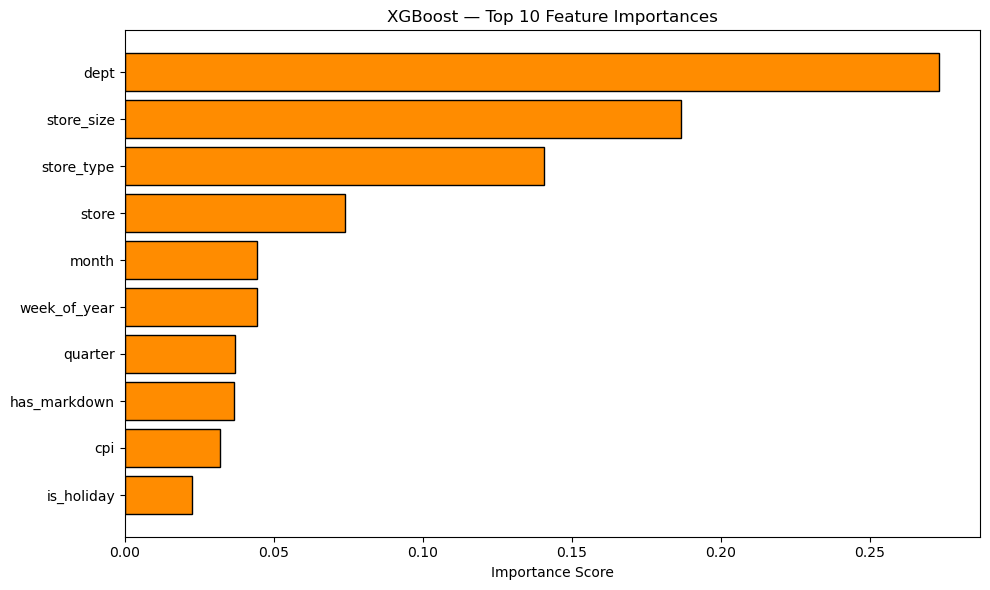

In [13]:
# Feature Importance

importance_df = pd.DataFrame({
    "feature"   : feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("\n── Top 10 Feature Importances ──")
print(importance_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"][:10][::-1],
    importance_df["importance"][:10][::-1],
    color="darkorange", edgecolor="black"
)
plt.title("XGBoost — Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.show()

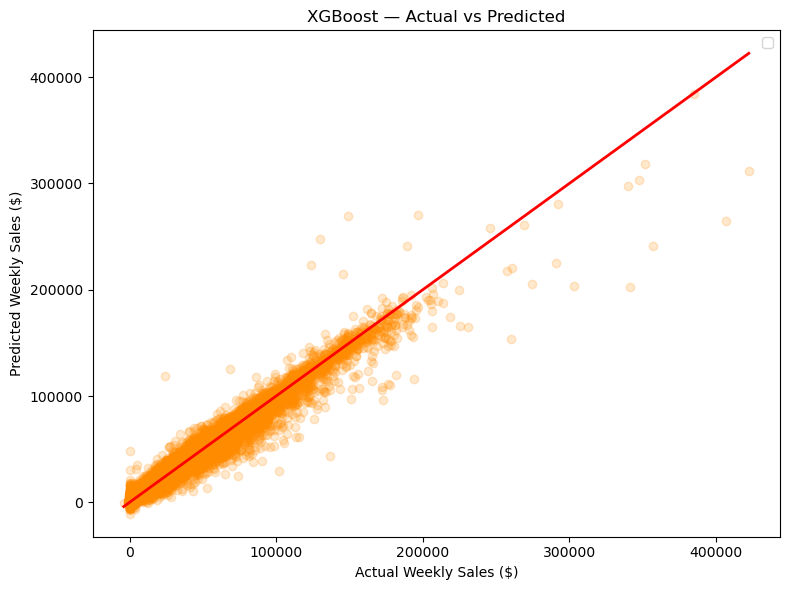

In [14]:
# Actual vs Predicted Plot:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, ypred_test, alpha=0.2, color="darkorange")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Weekly Sales ($)")
plt.ylabel("Predicted Weekly Sales ($)")
plt.title("XGBoost — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Save Model:
joblib.dump(xgb, "models/xgboost.pkl")
print("\n model saved → models/xgboost.pkl")


 model saved → models/xgboost.pkl


In [16]:
# Prediction Using XGBOOST Model on new data:
xgb = joblib.load("models/xgboost.pkl")

# Check it loaded correctly
print(f"Model type      : {type(xgb)}")
print(f"N estimators    : {xgb.n_estimators}")
print(f"Feature names   : {xgb.feature_names_in_}")

Model type      : <class 'xgboost.sklearn.XGBRegressor'>
N estimators    : 1000
Feature names   : ['store' 'dept' 'is_holiday' 'store_type' 'store_size' 'temperature'
 'fuel_price' 'markdown1' 'markdown2' 'markdown3' 'markdown4' 'markdown5'
 'cpi' 'unemployment' 'has_markdown' 'total_markdown' 'month' 'year'
 'week_of_year' 'quarter' 'is_quarter_end']


In [17]:
# Input must have exact same columns as training data:
input_data = pd.DataFrame([{
    "store"          : 1,
    "dept"           : 38,
    "is_holiday"     : 0,
    "store_type"     : 0,
    "store_size"     : 151315,
    "temperature"    : 62.5,
    "fuel_price"     : 3.2,
    "markdown1"      : 0,
    "markdown2"      : 0,
    "markdown3"      : 0,
    "markdown4"      : 0,
    "markdown5"      : 0,
    "cpi"            : 211.0,
    "unemployment"   : 7.2,
    "has_markdown"   : 0,
    "total_markdown" : 0,
    "month"          : 7,
    "year"           : 2026,
    "week_of_year"   : 27,
    "quarter"        : 3,
    "is_quarter_end" : 0
}])

prediction = xgb.predict(input_data)
print(f"Predicted Weekly Sales: ${prediction[0]:,.2f}")

Predicted Weekly Sales: $77,188.31


In [18]:
# Prediction Using RandomForest Model on new data:
xgb = joblib.load("models/random_forest.pkl")

# Check it loaded correctly
print(f"Model type      : {type(rf)}")
print(f"N estimators    : {rf.n_estimators}")
print(f"Feature names   : {rf.feature_names_in_}")

Model type      : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
N estimators    : 100
Feature names   : ['store' 'dept' 'is_holiday' 'store_type' 'store_size' 'temperature'
 'fuel_price' 'markdown1' 'markdown2' 'markdown3' 'markdown4' 'markdown5'
 'cpi' 'unemployment' 'has_markdown' 'total_markdown' 'month' 'year'
 'week_of_year' 'quarter' 'is_quarter_end']


In [19]:
# Input must have exact same columns as training data:
input_data = pd.DataFrame([{
    "store"          : 1,
    "dept"           : 38,
    "is_holiday"     : 0,
    "store_type"     : 0,
    "store_size"     : 151315,
    "temperature"    : 62.5,
    "fuel_price"     : 3.2,
    "markdown1"      : 0,
    "markdown2"      : 0,
    "markdown3"      : 0,
    "markdown4"      : 0,
    "markdown5"      : 0,
    "cpi"            : 211.0,
    "unemployment"   : 7.2,
    "has_markdown"   : 0,
    "total_markdown" : 0,
    "month"          : 7,
    "year"           : 2026,
    "week_of_year"   : 27,
    "quarter"        : 3,
    "is_quarter_end" : 0
}])

prediction = rf.predict(input_data)
print(f"Predicted Weekly Sales: ${prediction[0]:,.2f}")

Predicted Weekly Sales: $81,601.10
